In [5]:
from data_prep import *

In [11]:
df = load_data()

no of cols =25


In [16]:
data = df[(df.TradeDate==20100218)&(df.CallPut=='c')]
data[(data.AdjExpiry==20100319)&(data.Volume>0)&(data.Delta<.6)&(data.Delta>.04)][['TradeDate','ExpiryDate','AdjSpot','AdjStrike','px','Delta','ImpliedVolatility','Volume']].sort_values(by = 'AdjStrike')

,TradeDate,ExpiryDate,AdjSpot,AdjStrike,px,Delta,ImpliedVolatility,Volume
807,20100218,20100320,7.2475,7.142857,0.291071,0.586800,0.290319,6332.0
808,20100218,20100320,7.2475,7.500000,0.123214,0.343279,0.274313,8923.0
809,20100218,20100320,7.2475,7.857143,0.042679,0.153512,0.270239,6106.0
810,20100218,20100320,7.2475,8.214286,0.014107,0.059527,0.277886,1383.0


#####  critical date 20131031, 20120629

In [4]:
data = extract_clean_data(data,'c',20230630,test=True)

c options traded available on 20230630:438
option with expiry 20100319 and strike 10.357142857142858 vertical arbitrage
option with expiry 20100319 and strike 10.714285714285714 vertical arbitrage
option with expiry 20100416 and strike 10.0 vertical arbitrage
option with expiry 20100219 and strike 10.714285714285714 vertical arbitrage
option with expiry 20100716 and strike 11.428571428571429 vertical arbitrage
c options traded available on 20230630 after vertical arbitrage removed:214
c options traded available on 20230630 after calendar arbitrage removed:208
c options traded available on 20230630 after removing iv<.01 and iv>5:200


In [6]:
sufrace_genrator = GenSurface(data,interpolator='linear')
sufrace_genrator.surface

ImpliedVolatility                                        
time_to_exp          0.079452  0.156164  0.405479  0.923288  1.920548
AdjStrike                                                            
7.142857             0.290319  0.315114  0.346225  0.359485       NaN
7.500000             0.274313  0.300353  0.335853  0.352695  0.380240
7.857143             0.270239  0.293427  0.328179  0.346192  0.374812
8.214286             0.277886  0.287261  0.321835  0.341191  0.368432
8.571429                  NaN  0.287850  0.316896  0.336490  0.364092
8.928571                  NaN  0.294910  0.313620  0.332641  0.361705
9.285714                  NaN       NaN  0.311119  0.328886       NaN
9.642857                  NaN       NaN  0.309606  0.325957       NaN
10.000000                 NaN       NaN       NaN  0.323488  0.351406
10.357143                 NaN       NaN  0.312723  0.321962       NaN
10.714286                 NaN       NaN       NaN  0.320256  0.345340
11.071429                 NaN       NaN       NaN  0.319583  0.343160
11.428571                 NaN       NaN       NaN  0.317739  0.341121

In [9]:
sufrace_genrator_b = GenSurface(data)

In [7]:
sufrace_genrator.update_surface()
sufrace_genrator.surface

ImpliedVolatility                                        
time_to_exp          0.079452  0.156164  0.405479  0.923288  1.920548
AdjStrike                                                            
7.142857             0.290319  0.315114  0.346225  0.359485       NaN
7.500000             0.274313  0.300353  0.335853  0.352695  0.380240
7.857143             0.270239  0.293427  0.328179  0.346192  0.374812
8.214286             0.277886  0.287261  0.321835  0.341191  0.368432
8.571429                  NaN  0.287850  0.316896  0.336490  0.364092
8.928571                  NaN  0.294910  0.313620  0.332641  0.361705
9.285714                  NaN       NaN  0.311119  0.328886       NaN
9.642857                  NaN       NaN  0.309606  0.325957       NaN
10.000000                 NaN       NaN       NaN  0.323488  0.351406
10.357143                 NaN       NaN  0.312723  0.321962       NaN
10.714286                 NaN       NaN       NaN  0.320256  0.345340
11.071429                 NaN       NaN       NaN  0.319583  0.343160
11.428571                 NaN       NaN       NaN  0.317739  0.341121

In [10]:
sufrace_genrator_b.update_surface()

In [11]:
fwd_mnyness = sufrace_genrator.fwd_moneyness()

In [12]:
fwd_mnyness = sufrace_genrator_b.fwd_moneyness()

In [13]:
x,y = sufrace_genrator.known_data()
x,y = sufrace_genrator_b.known_data()

In [14]:
sufrace_genrator.gen_spline(s=.05)
sufrace_genrator_b.gen_spline(s=.05)

In [15]:
IV = sufrace_genrator.get_known_iv_surface()
IV = sufrace_genrator_b.get_known_iv_surface()


In [16]:
y_new = np.linspace(sufrace_genrator.known_y.min(), sufrace_genrator.known_y.max(), 100)

In [17]:
idx  =np.nanargmin(IV)
r, c = np.unravel_index(idx, [100,100])
print(r,c)

0 13


In [18]:
sufrace_genrator.abs_error()

Mean abs error: 2.0270926011414374e-18
Max abs error : 1.6653345369377348e-16


In [19]:
sufrace_genrator_b.abs_error()

Mean abs error: 0.004494524114250788
Max abs error : 0.028075280790332502


In [20]:
import matplotlib.pyplot as plt
        
def plot_volatility_surface(X, Y,Z):
    plt.style.use("default")
    sns.set_style("whitegrid", {"axes.grid": True})

    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X, Y,Z, cmap="coolwarm", alpha=0.9, linewidth=0, antialiased=True
    )

    ax.set_xlabel("Days to Expiry")
    ax.set_ylabel("Strike")
    ax.set_zlabel("Implied Volatility")
    ax.set_title("Volatility Surface, Spot=166.44,Trade Date = 20190131")
    ax.view_init(elev=90, azim=135)

    plt.tight_layout()
    plt.show()

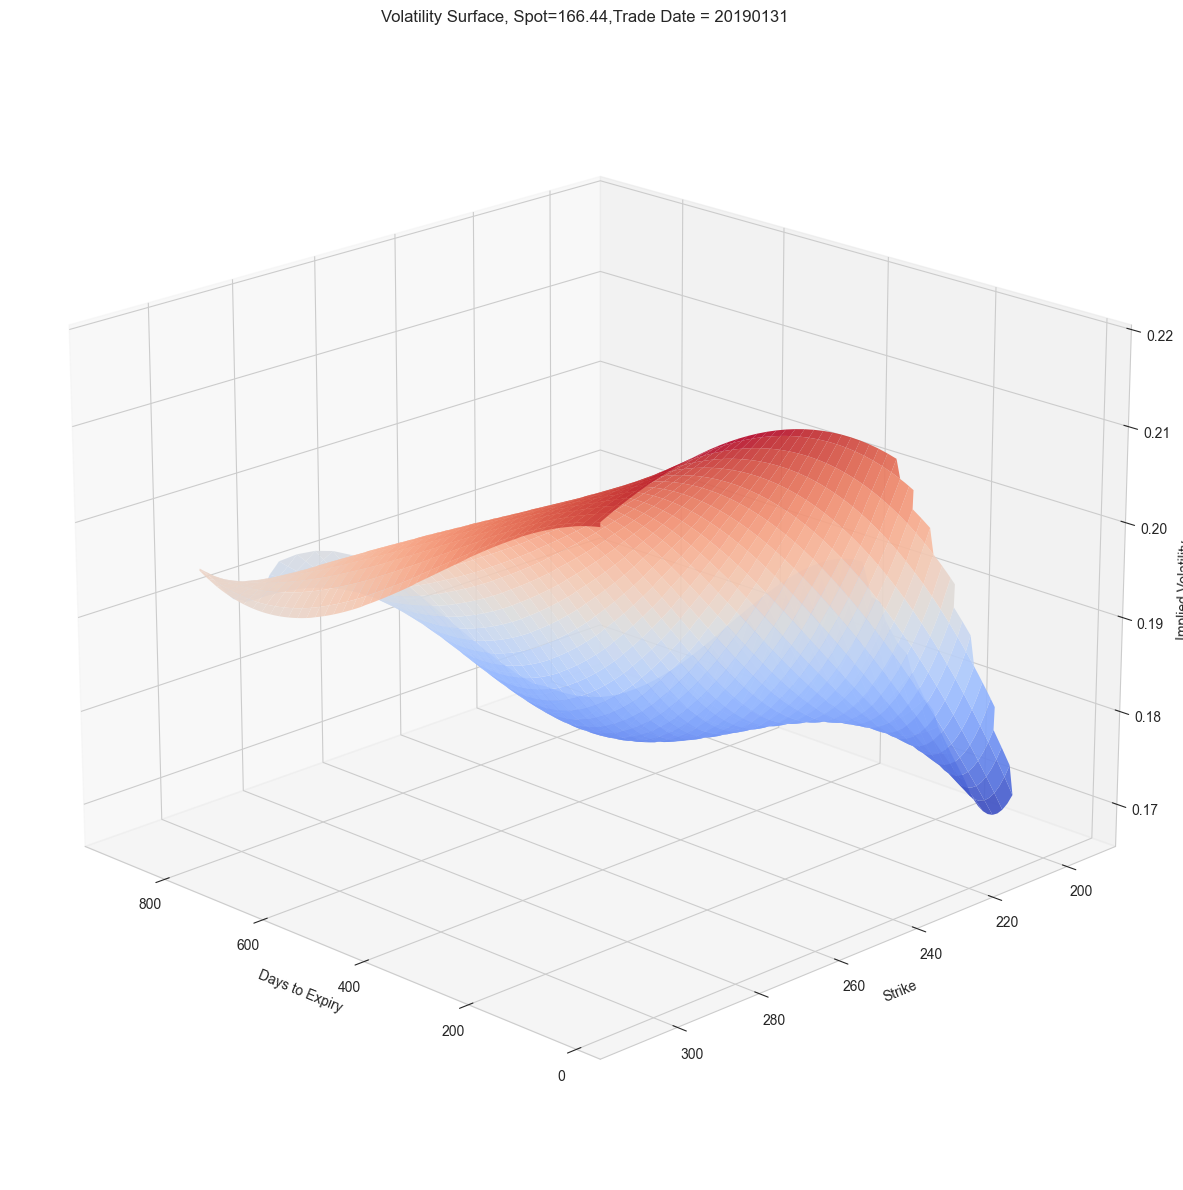

In [21]:
sufrace_genrator_b.plot_surface(elev=20,azim=135)

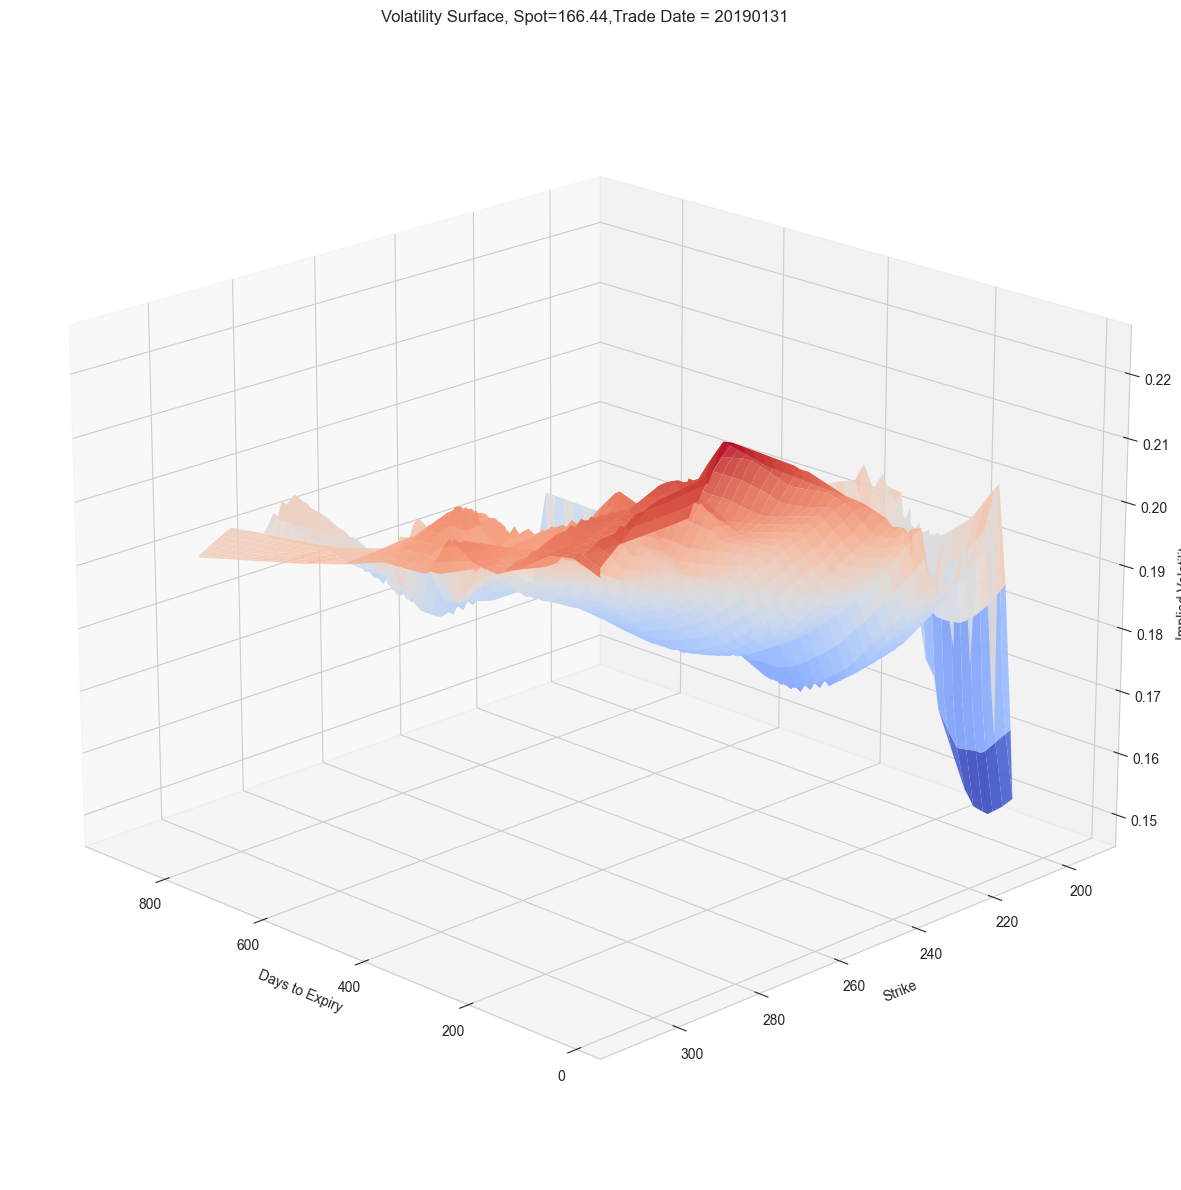

In [22]:
sufrace_genrator.plot_surface(elev=20,azim=135)

In [23]:
data[data.AdjExpiry==20240621][['AdjStrike','ImpliedVolatility','px','Delta','days_to_expiry','risk_free_rate','AdjSpot']].sort_values(by='AdjStrike')

,AdjStrike,ImpliedVolatility,px,Delta,days_to_expiry,risk_free_rate,AdjSpot
527,200.0,0.218332,18.600,0.581368,357,0.052809,193.97
547,205.0,0.209748,15.700,0.534306,357,0.052809,193.97
567,210.0,0.204987,13.300,0.485828,357,0.052809,193.97
586,215.0,0.202619,11.300,0.438124,357,0.052809,193.97
606,220.0,0.195999,9.200,0.387345,357,0.052809,193.97
625,225.0,0.196030,7.800,0.343810,357,0.052809,193.97
645,230.0,0.192594,6.350,0.298722,357,0.052809,193.97
664,235.0,0.190840,5.200,0.258290,357,0.052809,193.97
684,240.0,0.189669,4.250,0.221829,357,0.052809,193.97
703,245.0,0.188590,3.450,0.188880,357,0.052809,193.97


In [24]:
sufrace_genrator.get_implied_volatility(357,0.052809,280,193.97)

array(0.17567381)

In [25]:
sufrace_genrator.compute_px('c',20230630,193.97,357,0.052809,280)

(np.float64(0.5400027906423602),
 0.041930721387765796,
 np.float64(0.002656754906368091),
 np.float64(0.171752471491072),
 np.float64(-0.005324443056910178),
 np.float64(0.07426870760516424))

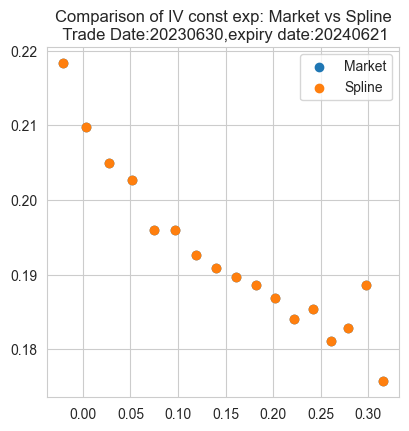

In [26]:
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(2,2, 1)
sufrace_genrator.scatter_plot_iv_exp(ax,20240621)

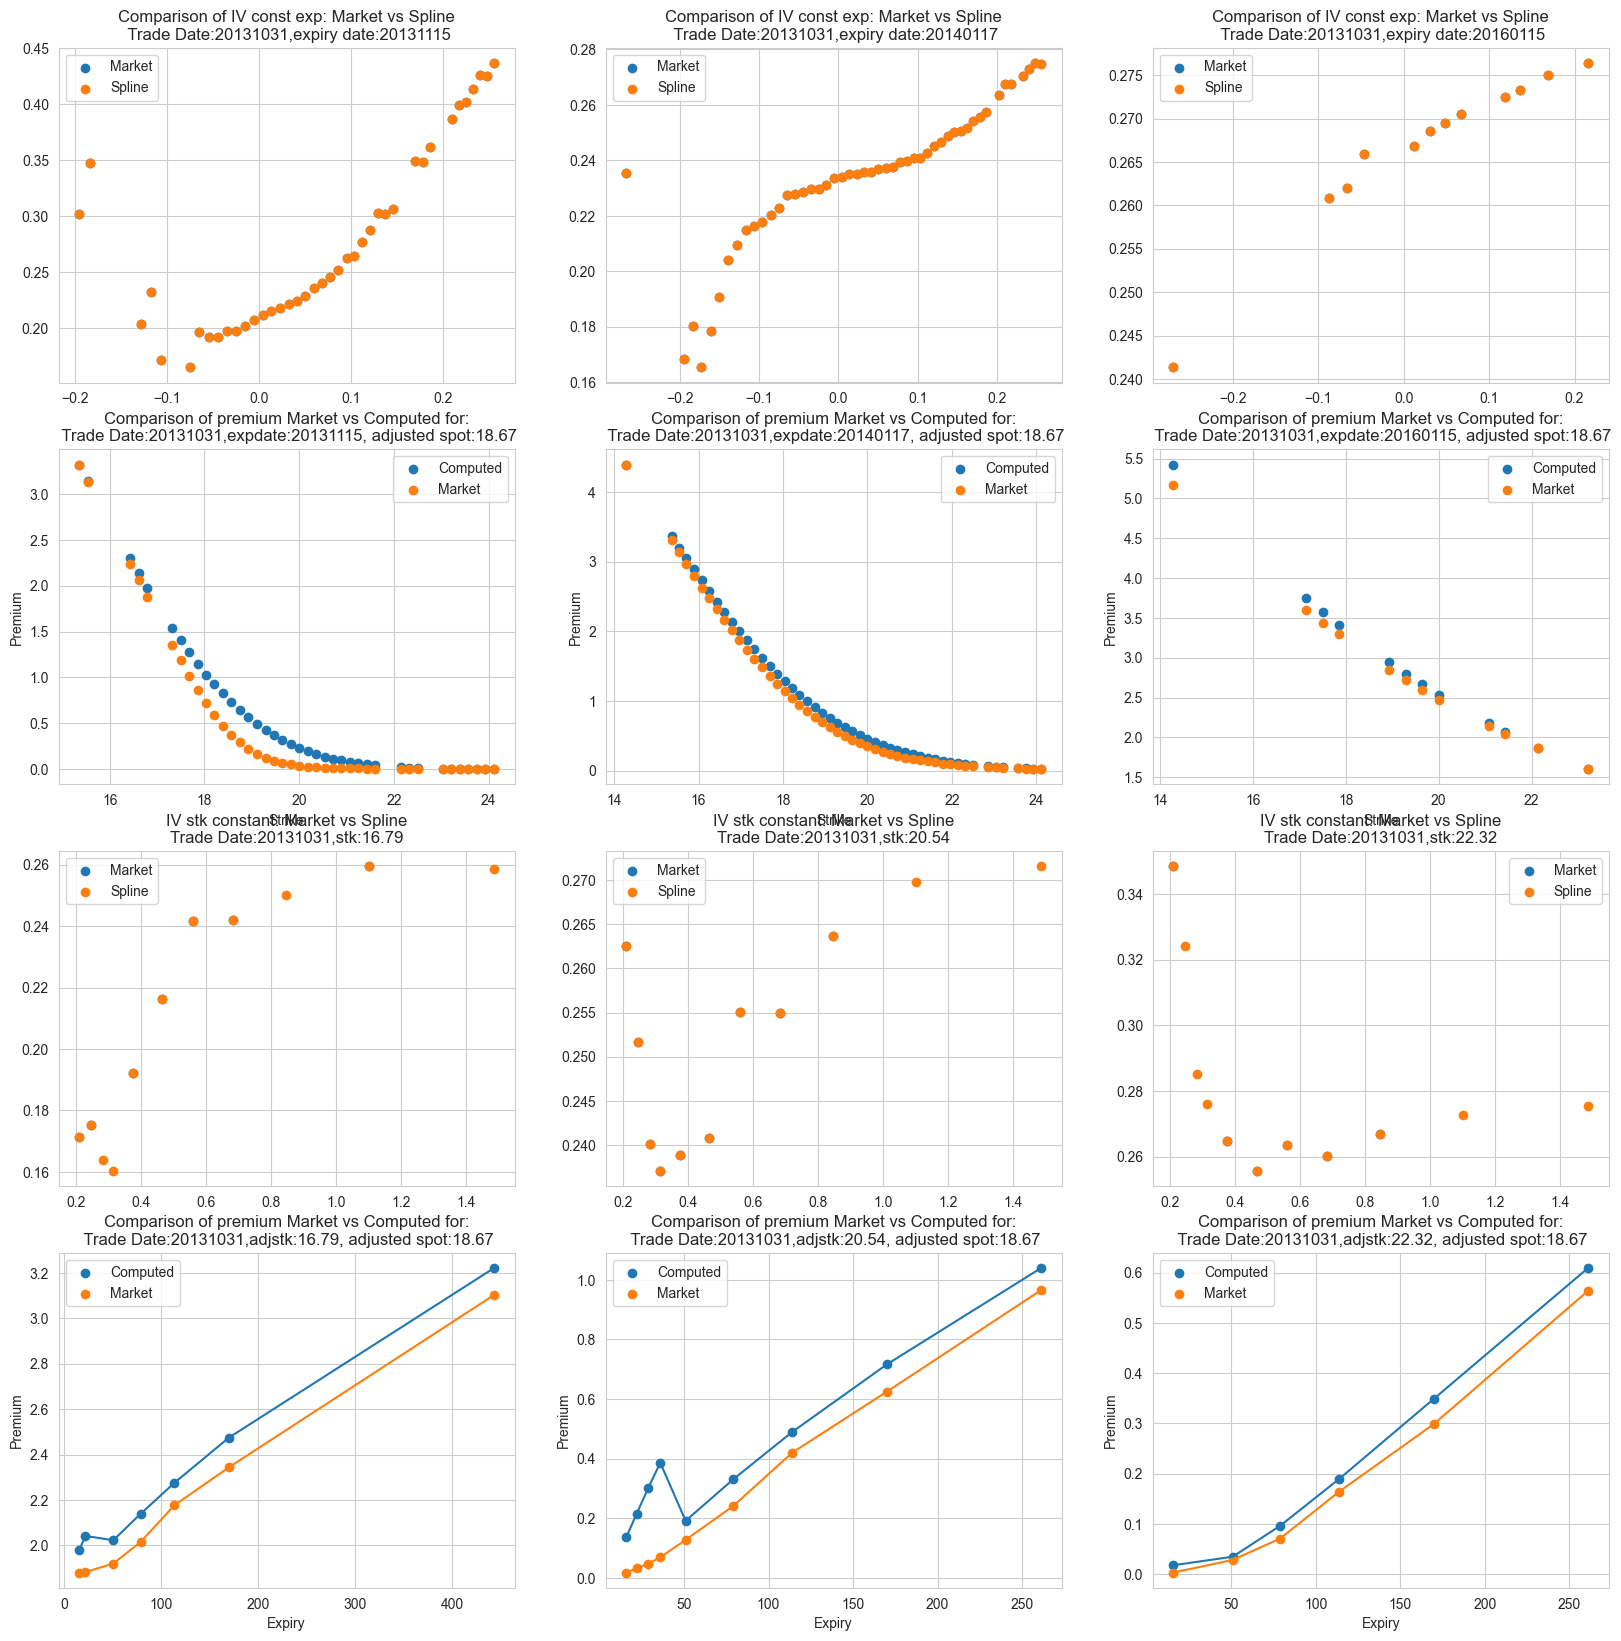

In [21]:
sufrace_genrator.plot_simulation_results()

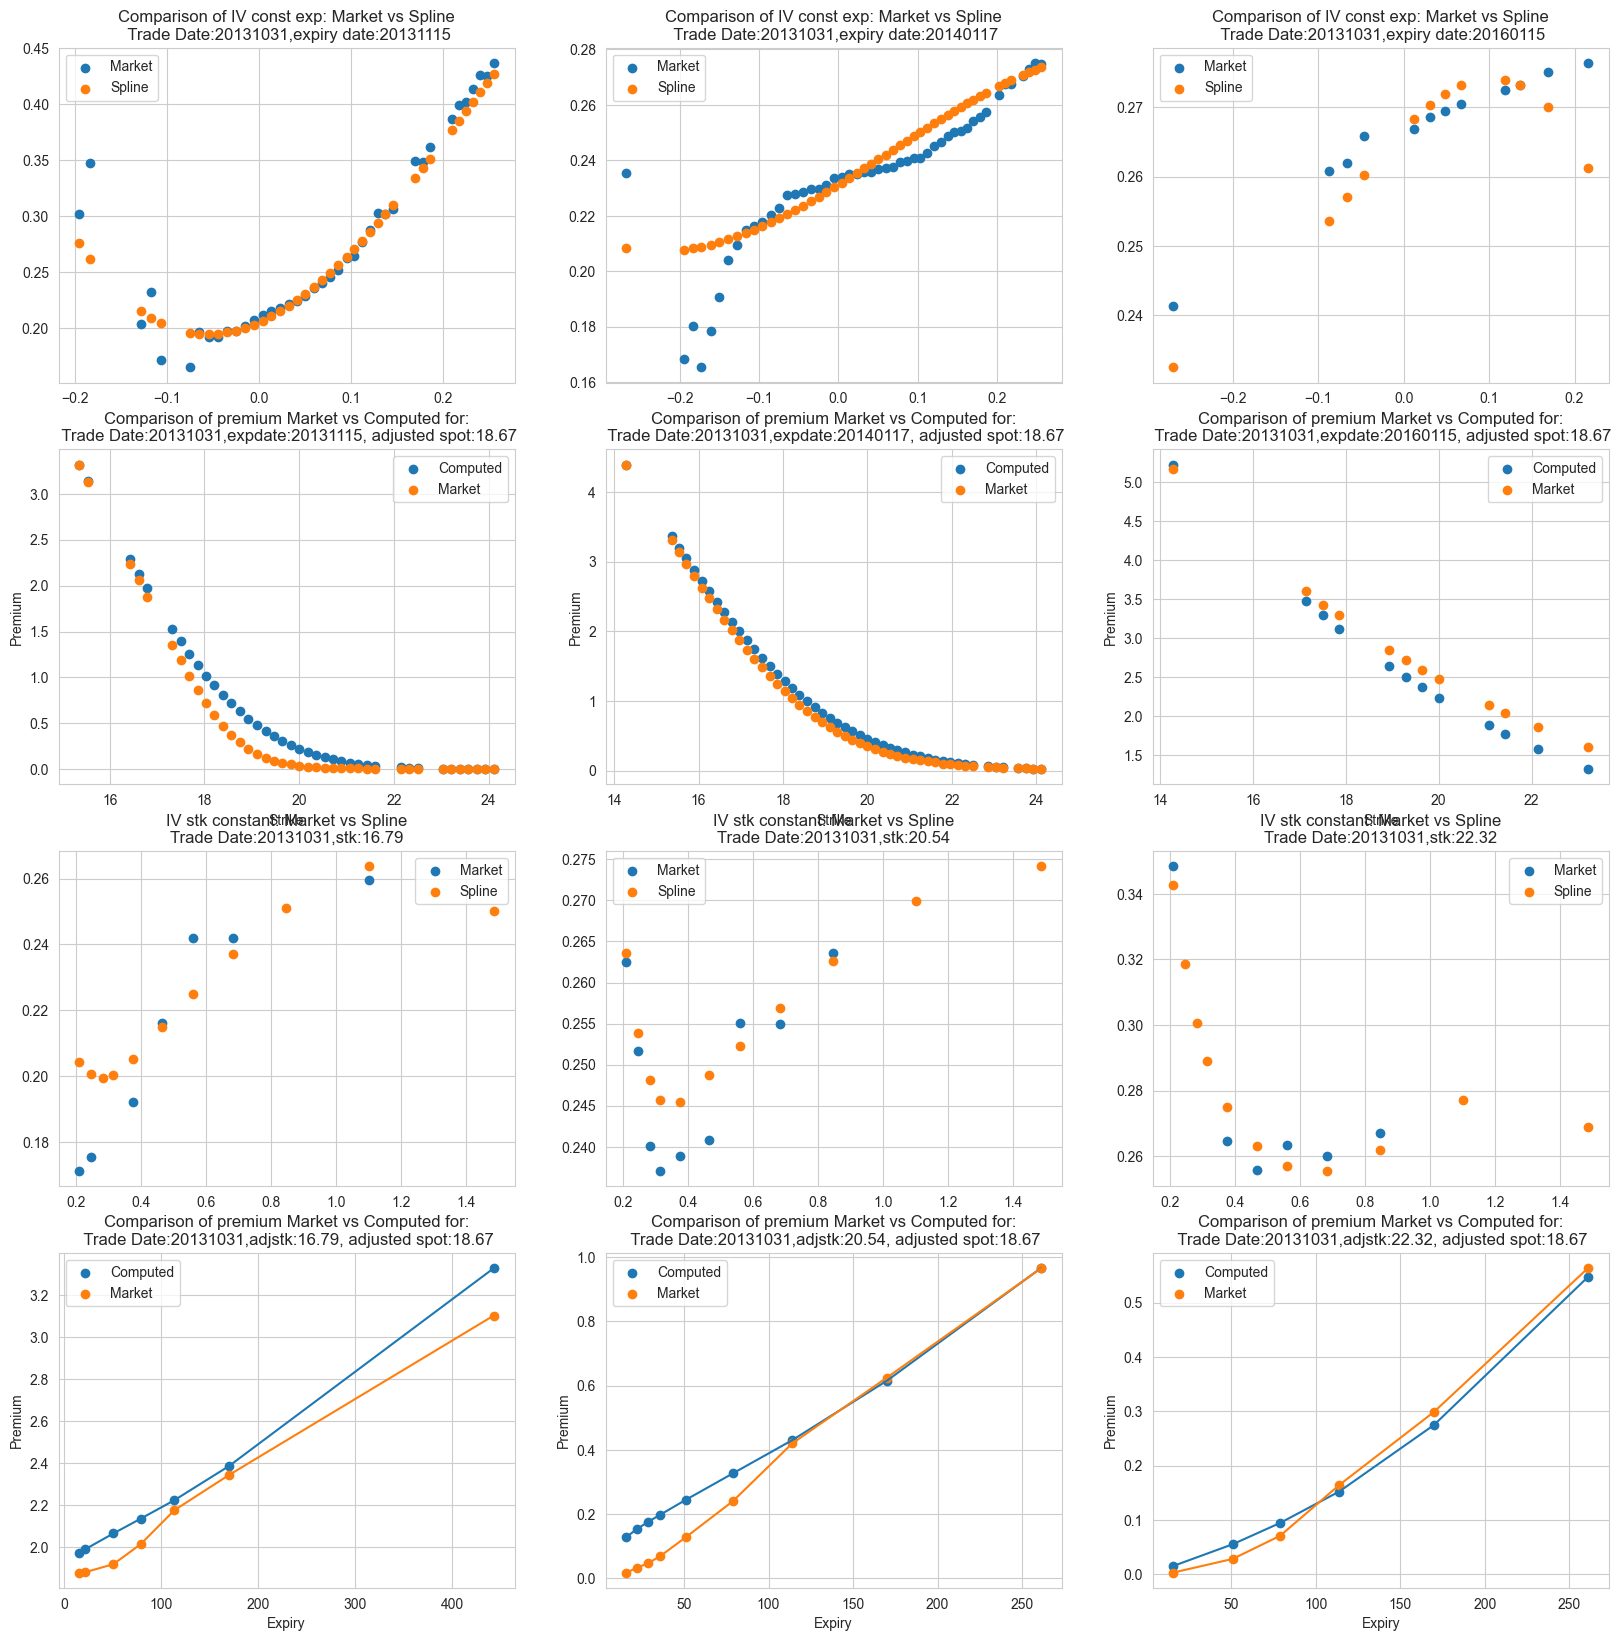

In [37]:
sufrace_genrator_b.plot_simulation_results()

In [38]:
sufrace_genrator.data

,TradeDate,AdjExpiry,CallPut,ImpliedVolatility,Spot,AdjSpot,Strike,AdjStrike,risk_free_rate,time_to_exp,days_to_expiry,px,AbsMoneyness
155,20131031,20150116,c,0.218882,522.7,18.67,370.0,13.21,0.000900,1.213699,443,5.6010,70.755222
162,20131031,20150116,c,0.224267,522.7,18.67,375.0,13.39,0.000900,1.213699,443,5.4535,71.719336
168,20131031,20150116,c,0.229048,522.7,18.67,380.0,13.57,0.000900,1.213699,443,5.3090,72.683449
181,20131031,20140417,c,0.160603,522.7,18.67,390.0,13.93,0.000767,0.465753,170,4.7470,74.611676
183,20131031,20150116,c,0.238212,522.7,18.67,390.0,13.93,0.000900,1.213699,443,5.0325,74.611676
...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,20131031,20140417,c,0.266962,522.7,18.67,670.0,23.93,0.000767,0.465753,170,0.1535,128.173540
778,20131031,20150116,c,0.275497,522.7,18.67,670.0,23.93,0.000900,1.213699,443,0.7465,128.173540
780,20131031,20131115,c,0.436922,522.7,18.67,675.0,24.11,0.000300,0.043836,16,0.0015,129.137654
784,20131031,20140117,c,0.274755,522.7,18.67,675.0,24.11,0.000392,0.216438,79,0.0230,129.137654


In [39]:
valid_px = sufrace_genrator.data[sufrace_genrator.data.px>0].px.min()
valid_px

0.0015